In [5]:
df = pd.read_html("Agmarknet_Price_Report.xls")[0]
print(df.columns.tolist())


['Sl no.', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)', 'Price Date']


In [8]:
import pandas as pd

# Step 1: Read the file
df = pd.read_html("Agmarknet_Price_Report.xls")[0]

# Step 2: Clean column names (strip spaces, fix weird characters)
df.columns = df.columns.str.strip().str.replace("\xa0", " ", regex=True)

# Step 3: Drop empty rows
df.dropna(how="all", inplace=True)

# Step 4: Convert price columns to numeric
for col in [
    "Min Price (Rs./Quintal)",
    "Max Price (Rs./Quintal)",
    "Modal Price (Rs./Quintal)"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Step 5: Convert date column
df["Price Date"] = pd.to_datetime(df["Price Date"], errors="coerce")

# Step 6: Reset index
df.reset_index(drop=True, inplace=True)

# Step 7: Preview cleaned data
df.head()


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,1,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,100,300,200,2025-05-05
1,2,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,NaT
2,3,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,NaT
3,4,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,250,NaT
4,5,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,300,NaT


In [11]:
df = df.dropna(subset=["Price Date"])


In [12]:
df.head()

,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,1,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,100,300,200,2025-05-05
1,2,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,2025-05-05
2,3,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,2025-05-05
3,4,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,250,2025-05-05
4,5,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,300,2025-05-05


In [13]:
# Save to Excel
df.to_excel("cleaned_agmarknet_data.xlsx", index=False, engine="openpyxl")

# OR save as CSV
df.to_csv("cleaned_agmarknet_data.csv", index=False)


In [14]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Optional: make plots look better
sns.set(style="whitegrid")


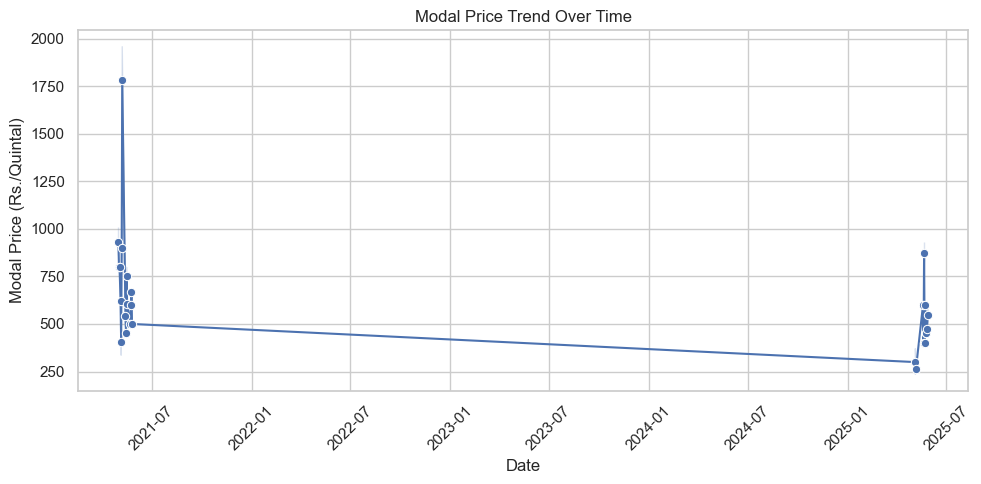

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="Price Date", y="Modal Price (Rs./Quintal)", marker="o")
plt.title("Modal Price Trend Over Time")
plt.ylabel("Modal Price (Rs./Quintal)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


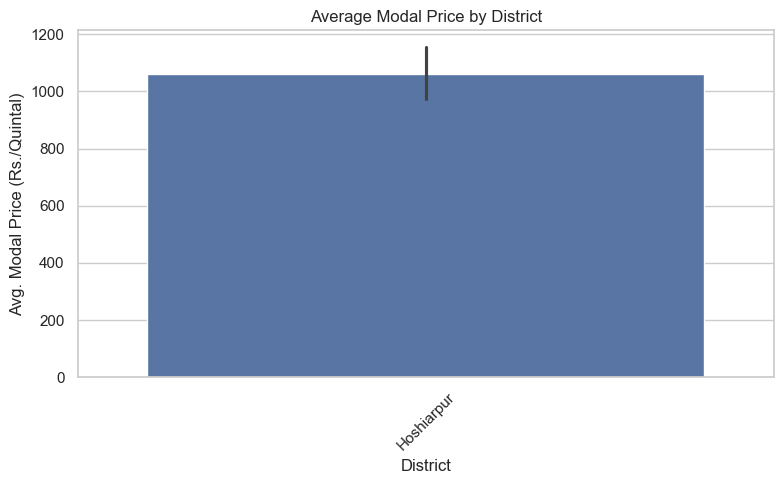

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="District Name",
    y="Modal Price (Rs./Quintal)",
    estimator="mean"
)
plt.title("Average Modal Price by District")
plt.ylabel("Avg. Modal Price (Rs./Quintal)")
plt.xlabel("District")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


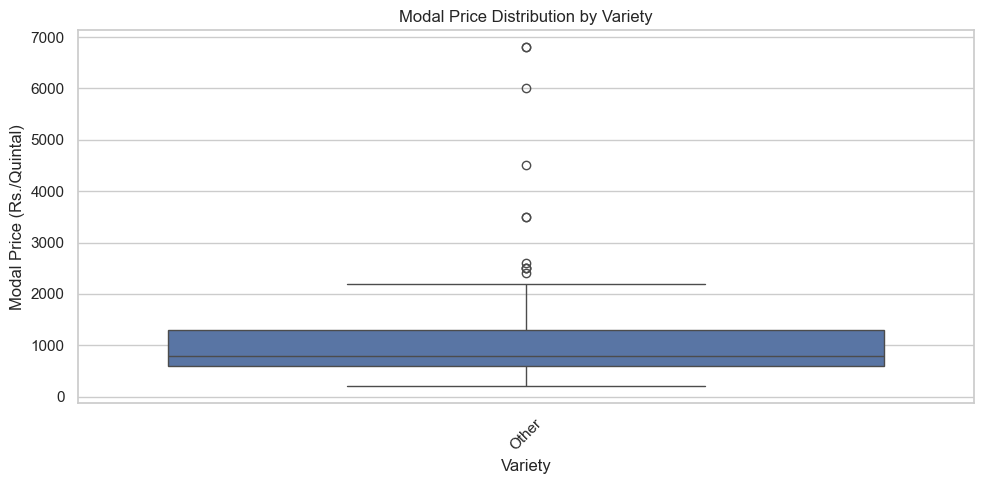

In [23]:
# Rename column
df = df.rename(columns={
    "Modal Price (Rs./Quintal)": "Modal Price"
})

# Now plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Variety", y="Modal Price")
plt.title("Modal Price Distribution by Variety")
plt.ylabel("Modal Price (Rs./Quintal)")
plt.xlabel("Variety")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
